In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

**Lax–Friedrichs method**

For a system

$\qquad\qquad\displaystyle
\frac{\partial u}{\partial t} + a \frac{\partial u}{\partial x} = 0
$

Replace time derivative (forward difference)

$\qquad\qquad\displaystyle
\frac{u_i^{n+1} - u_i^n}{\Delta t}
$

the “Lax trick”

Instead of $u_i^n$, use an **average of neighbors**:

$\qquad\qquad\displaystyle u_i^n \;\to\; \frac{u_{i+1}^n + u_{i-1}^n}{2}$

This adds **artificial diffusion** → stabilizes the scheme.

Spatial derivative (central difference)

$\qquad\qquad\displaystyle
\frac{\partial u}{\partial x}
\approx
\frac{u_{i+1}^n - u_{i-1}^n}{2\Delta x}
$

Lax–Friedrichs scheme

$\qquad\qquad\displaystyle
u_i^{n+1}=\frac{1}{2}(u_{i+1}^n + u_{i-1}^n) -\frac{a\Delta t}{2\Delta x}(u_{i+1}^n - u_{i-1}^n)$

Why it works (important insight)

Rewrite as:

$\qquad\qquad\displaystyle 
u_i^{n+1} = u_i^n - \frac{a\Delta t}{2\Delta x}(u_{i+1}^n - u_{i-1}^n)+\frac{1}{2}(u_{i+1}^n - 2u_i^n + u_{i-1}^n)$

* Last term = **numerical diffusion**
* That’s what stabilizes it

Stability condition (CFL)

$\qquad\qquad\displaystyle \left|\frac{a\Delta t}{\Delta x}\right| \le 1$


**Lax–Wendroff method**  

Standard form:

$\qquad\qquad\displaystyle \frac{\partial u}{\partial t} + a \frac{\partial u}{\partial x} = 0$

Taylor expand in time

$\qquad\qquad\displaystyle
u(x,t+\Delta t) =u + \Delta t,u_t + \frac{\Delta t^2}{2}u_{tt}$

Use PDE:

* $\qquad\qquad\displaystyle u_t = -a u_x$
* $\qquad\qquad\displaystyle u_{tt} = -a (u_x)*t = a^2 u*{xx}$

Substitute:

$\qquad\qquad\displaystyle
u^{n+1} =u^n - a\Delta t\,u_x + \frac{a^2 \Delta t^2}{2} u_{xx}$

Replace derivatives (finite differences)

$\qquad\qquad\displaystyle
u_x \approx \frac{u_{i+1}^n - u_{i-1}^n}{2\Delta x}
\quad,\quad
u_{xx} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}
$

Lax–Wendroff scheme

$\qquad\qquad\displaystyle
u_i^{n+1}=u_i^n -\frac{a\Delta t}{2\Delta x}(u_{i+1}^n - u_{i-1}^n)
+\frac{a^2\Delta t^2}{2\Delta x^2}(u_{i+1}^n -2u_i^n + u_{i-1}^n)$

Applying to Schrödinger (formal)

Write Schrödinger as:

$\qquad\qquad\displaystyle  \frac{\partial \Psi}{\partial t}=\frac{i\hbar}{2m}\frac{\partial^2 \Psi}{\partial x^2}+ \frac{i}{\hbar}V\Psi$

You’d apply Lax–Wendroff separately to each term, but:

Problem:

* Equation is **not hyperbolic**
* Method is **not unitary**
* Leads to **instability / wrong physics**


Stability condition (CFL)

$\qquad\qquad\displaystyle
\left|\frac{a\Delta t}{\Delta x}\right| \le 1$


<span style="color:red">Problem 5.11                                                                                                                                                  
Implement the Richtmyer two-step (Lax–Wendroff) method in full nonlinear form.                                                                               
We’ll test its behavior on the linear problem, where $v(x, 0) = v_m$.                                                                                               
(a) Run the method for $\Delta x = 0.01, v_m = 50, \Delta t = \frac{\Delta x}{v_m}$, and periodic boundary conditions using $u(x, 0) = \sin(2\pi x)$ with $x \in [0, 1 + \Delta x]$                                                                                                                              
(you have to go one step beyond the target endpoint to employ periodic boundary conditions).                             
Run for two hundred steps and make a movie of the resulting traveling wave.                                                                                  
(b) Try using all the same values, but set $\Delta t = 1.1\frac{\Delta x}{v_m}$. Can you see the lack of stability in the solution?

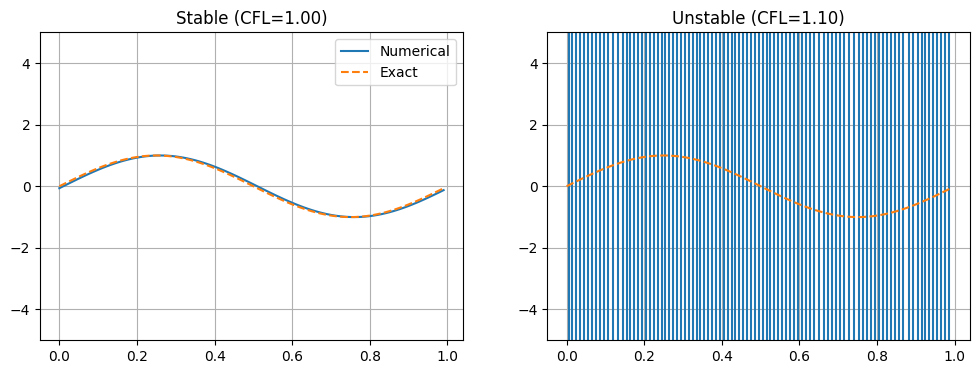

In [2]:
dx = 0.01
vm = 50
dt_stable   = dx / vm
dt_unstable = 1.1 * dx / vm
steps = 200
x = np.arange(0, 1, dx)
N = len(x)

def flux(u):
    return vm * u

def richtmyer(u, dt):

    uh = np.zeros(N)
    for j in range(N):
        jp = (j + 1) % N
        uh[j] = 0.5*(u[jp] + u[j]) - (dt/(2*dx))*(flux(u[jp]) - flux(u[j]))

    unew = np.zeros(N)
    for j in range(N):
        jm = (j - 1) % N
        unew[j] = u[j] - (dt/dx)*(flux(uh[j]) - flux(uh[jm]))

    return unew

u_stable   = np.sin(2*np.pi*x)
u_unstable = np.sin(2*np.pi*x)

for n in range(steps+1):
    u_stable   = richtmyer(u_stable, dt_stable)
    u_unstable = richtmyer(u_unstable, dt_unstable)
    x_exact = (x - vm*n*dt_stable) % 1
    u_exact = np.sin(2*np.pi*x_exact)
    
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    ax1.plot(x, u_stable, label="Numerical")
    ax1.plot(x, u_exact, '--', label="Exact")
    ax1.set_title(f"Stable (CFL={vm*dt_stable/dx:.2f})")
    ax1.set_ylim(-5, 5)
    ax1.legend()
    ax1.grid()
 
    ax2.plot(x, u_unstable)
    ax2.plot(x, u_exact, '--', label="Exact")
    ax2.set_title(f"Unstable (CFL={vm*dt_unstable/dx:.2f})")
    ax2.set_ylim(-5, 5)
    ax2.grid()

    plt.show()

<span style="color:red">Problem 5.12          
Take the wave equation, $\displaystyle \frac{\partial u}{\partial t} + \frac{\partial}{\partial x} \big( v_m\,u \big) = 0$  with $v_m = 1.0$, and set      
$\qquad\qquad\displaystyle u(x, 0) = \begin{cases}1, & x \le 0.5 \\ 0, & x > 0.5\end{cases}\tag{5.84}$                                                       
the initial conditions appropriate to the Riemann problem. For both the Lax–Friedrichs and Lax–Wendroff methods,                                                                                                        
let $\Delta x = 0.01, \Delta t = \frac{\Delta x}{2}$, and use $101$ spatial grid points
($i.e. x \in [0, 1]$) with “diffuse” boundary conditions.                                                                                                   
Run for 100 time steps and make a movie of the output.                                                                                                      
We know that the solution $u(x, t )$ is just the initial waveform $u(x, 0)$ moving to the right with speed $v_m$.                                                  
But both numerical solvers fail to resolve the discontinuity perfectly,                                                                                      
and they do so in ways that are typical of their application to more complicated (nonlinear) 
problems                                                     
 (one of the solvers smooths out th  discontinuity, the other exhibits a 
oscillatory overshoot).

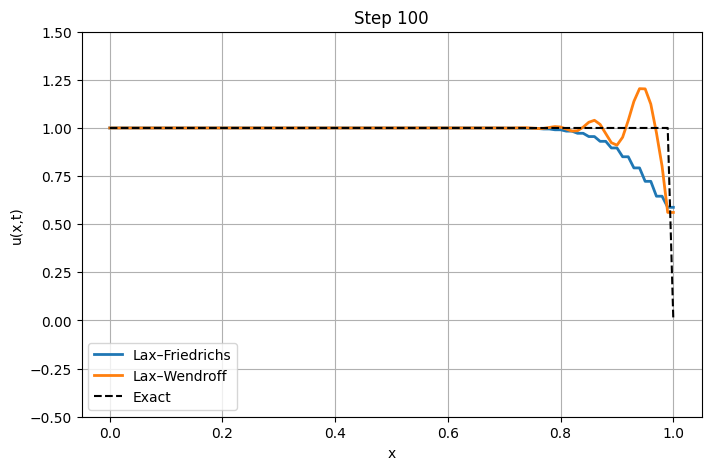

In [3]:
vm = 1.0
dx = 0.01
dt = dx / 2
N = 101
x = np.linspace(0, 1, N)
steps = 100
c = vm * dt / dx   # CFL number should be 0.5
u0 = np.zeros(N)
u0[x <= 0.5] = 1.0
u_LF = u0.copy()
u_LW = u0.copy()

def apply_bc(u):
    u[0]  = u[1]
    u[-1] = u[-2]
    return u

for n in range(steps):

    u_LF_new = u_LF.copy()
    u_LW_new = u_LW.copy()

    # ----- Lax–Friedrichs -----
    for j in range(1, N-1):
        u_LF_new[j] = 0.5*(u_LF[j+1] + u_LF[j-1]) - 0.5*c*(u_LF[j+1] - u_LF[j-1])
    u_LF = apply_bc(u_LF_new)

    # ----- Lax–Wendroff -----
    for j in range(1, N-1):
        u_LW_new[j] = (u_LW[j] - 0.5*c*(u_LW[j+1] - u_LW[j-1]) + 0.5*c**2*(u_LW[j+1] - 2*u_LW[j] + u_LW[j-1]))
    u_LW = apply_bc(u_LW_new)

    # ----- Exact ----------
    x_exact = x - vm * n * dt
    u_exact = np.zeros_like(x)
    u_exact[x_exact <= 0.5] = 1
    
    clear_output(wait=True)
    plt.figure(figsize=(8,5))
    plt.plot(x, u_LF, label="Lax–Friedrichs", linewidth=2)
    plt.plot(x, u_LW, label="Lax–Wendroff", linewidth=2)
    plt.plot(x, u_exact, '--', label="Exact", color='black')
    plt.title(f"Step {n+1}")
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.ylim(-0.5, 1.5)
    plt.legend(loc='lower left')
    plt.grid()
    plt.show()

<span style="color:red">Problem 5.13                                                                                                                                                 
Imagine a medium made of two different materials placed next to each other in a repeating pattern                                                        
(glass, for example, with different index of refraction).                                                                                                                                                 
The characteristic speed in each material is different, so we have an alternating pattern of speeds.                                                         
Such a configuration could be modeled by letting:                                                                                                           
$\qquad\qquad\displaystyle v(x) = v_m \sin^2(2\pi f x) \tag{5.85}$                                                                                           
where $v(x)$ goes from $v_m$ to zero in an oscillatory manner.                                                                                                    
Solve $\displaystyle \frac{\partial u}{\partial t} + \frac{\partial}{\partial x} \big( v\,u \big) = 0$ 
 using Lax–Friedrichs with zero boundary conditions given the above $v(x)$.                                                                                  
Work on $x \in [0, 1]$ with $\Delta x = 0.005, v_m = 50, \Delta t = \frac{\Delta x}{v_m}$, and $f = 5$.                                                    
Take a sharply peaked Gaussian as the initial wave function : $\displaystyle u(x, 0) = e^{−100(x−\frac12)^2}$ and run two hundred steps of the solver using “zeroed” boundaries.

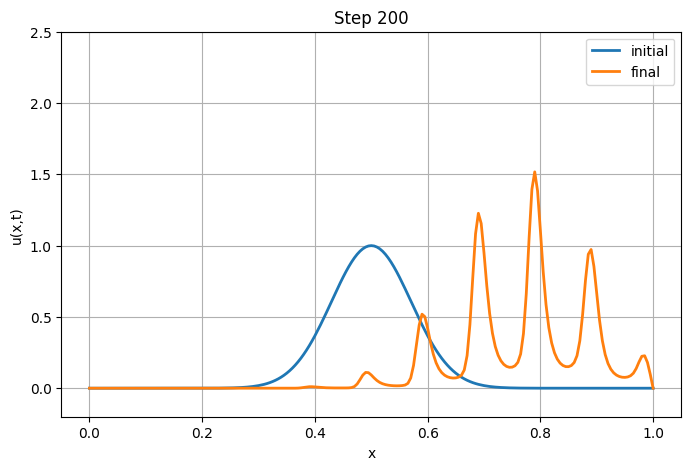

In [4]:
vm = 50
dx = 0.005
dt = dx / vm
f  = 5
x = np.arange(0, 1 + dx, dx)
N = len(x)
steps = 200
v = vm * (np.sin(2 * np.pi * f * x))**2
u = np.exp(-100 * (x - 0.5)**2)
u_init = u.copy()

for n in range(steps):
    u_new = u.copy()
    for j in range(1, N-1):
        flux_right = v[j+1] * u[j+1]
        flux_left  = v[j-1] * u[j-1]
        u_new[j] = 0.5*(u[j+1] + u[j-1]) - (dt/(2*dx)) * (flux_right - flux_left)
    u_new[0]  = 0
    u_new[-1] = 0
    u = u_new
    
    clear_output(wait=True)
    plt.figure(figsize=(8,5))
    plt.plot(x, u_init, linewidth=2, label='initial')
    plt.plot(x, u, linewidth=2, label='final')
    plt.title(f"Step {n+1}")
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.ylim(-0.2, 2.5)
    plt.legend()
    plt.grid()
    plt.show()

<span style="color:red">Problem 5.14                                                                                                                                                    
Solve the Riemann problem for traffic flow using the Lax–Wendroff solver (with “diffuse” boundary conditions) –                                             
use, as in Section 5.1.4,  $v_m = 65, \rho_l  = 0, \rho_r = \frac12\rho_m$ with $\rho_m = 264$.                                                                                         
Run on a grid with $\Delta x = 0.01$ for $x \in [0, 10]$ – switch from $\rho_l$ to $\rho_r$ at $x = 5$ initially.                                             
Take 200 steps in time and calculate the speed of the discontinuity. Does it match the prediction in (5.27)?                                              
Try it with the Lax–Friedrichs solver and $\rho_r=\rho_m, \rho_l=\frac12\rho_m$, and again check the “shock speed.”

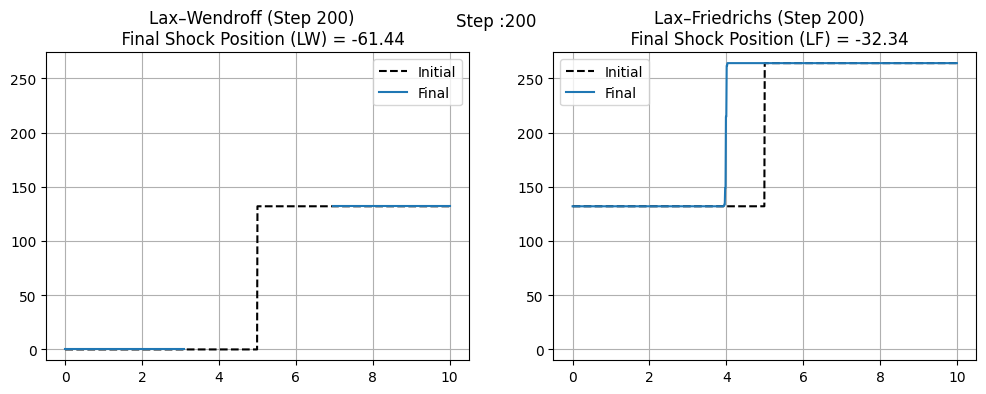

In [5]:
vm = 65
rho_m = 264
dx = 0.01
x = np.arange(0, 10 + dx, dx)
N = len(x)
dt = dx / vm
steps = 200

def flux(rho):
    return vm * rho * (1 - rho / rho_m)

rho_LW = np.zeros(N)
rho_LW[x >= 5] = 0.5 * rho_m   # Lax–Wendroff case

rho_LF = np.zeros(N)
rho_LF[x < 5]  = 0.5 * rho_m
rho_LF[x >= 5] = rho_m         # Lax–Friedrichs case

rho_LW_init = rho_LW.copy()
rho_LF_init = rho_LF.copy()
rho_series_LW = []
rho_series_LF = []

def apply_bc(r):
    r[0]  = r[1]
    r[-1] = r[-2]
    return r

def shock_track(rho_series, x, dt):
    positions = []
    for rho in rho_series:
        grad = np.abs(np.diff(rho))
        positions.append(x[np.argmax(grad)])
    return (positions[-1] - positions[0]) / (len(rho_series)*dt)

for n in range(steps+1):

    # ===== Lax–Wendroff =====
    rho_new = rho_LW.copy()
    for j in range(1, N-1):
        rho_new[j] = (rho_LW[j] - (dt/(2*dx))*(flux(rho_LW[j+1]) - flux(rho_LW[j-1])) 
                      + (dt**2/(2*dx**2)) * ((flux(rho_LW[j+1]) - flux(rho_LW[j])) - (flux(rho_LW[j])   - flux(rho_LW[j-1]))))
    rho_LW = apply_bc(rho_new)

    # ===== Lax–Friedrichs =====
    rho_new = rho_LF.copy()
    for j in range(1, N-1):
        rho_new[j] = 0.5*(rho_LF[j+1] + rho_LF[j-1]) - (dt/(2*dx))*(flux(rho_LF[j+1]) - flux(rho_LF[j-1]))
    rho_LF = apply_bc(rho_new)
    
    rho_series_LW.append(rho_LW.copy())
    rho_series_LF.append(rho_LF.copy())
    speed_LW = shock_track(rho_series_LW, x, dt)
    speed_LF = shock_track(rho_series_LF, x, dt)
    
    if n % 10 == 0:
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

        # ---- Lax–Wendroff ----
        ax1.plot(x, rho_LW_init, 'k--', label="Initial")
        ax1.plot(x, rho_LW, label="Final")
        ax1.set_title(f"Lax–Wendroff (Step {n})  \n  Final Shock Position (LW) = {speed_LW:.2f}")
        ax1.set_ylim(-10, rho_m+10)
        ax1.legend()
        ax1.grid()

        # ---- Lax–Friedrichs ----
        ax2.plot(x, rho_LF_init, 'k--', label="Initial")
        ax2.plot(x, rho_LF, label="Final")
        ax2.set_title(f"Lax–Friedrichs (Step {n})  \n  Final Shock Position (LF) = {speed_LF:.2f}")
        ax2.set_ylim(-10, rho_m+10)
        ax2.legend()
        ax2.grid()
        fig.suptitle(f'Step :{n}')
        plt.show()

# ✦ Lax–Friedrichs scheme for Schrödinger equation

 Given equation

$\qquad\qquad\displaystyle
i\hbar \frac{\partial \Psi}{\partial t}=-\frac{\hbar^2}{2m}\frac{\partial^2 \Psi}{\partial x^2}+ V(x)\Psi$


Rewriting 

$\qquad\qquad\displaystyle \frac{\partial \Psi}{\partial t}=\alpha \Psi_{xx} + \beta \Psi$

where $\qquad\qquad\displaystyle\alpha = \frac{i\hbar}{2m}\, \quad \beta = -\frac{i}{\hbar}V(x)$

**Lax–Friedrichs idea**

Replace $\Psi_i^n$ by average 

$\qquad\qquad\displaystyle \Psi_i^n \;\to\; \frac{\Psi_{i+1}^n + \Psi_{i-1}^n}{2}$

Time derivative (forward difference) 

$\qquad\qquad\displaystyle\frac{\Psi_i^{n+1} - \Psi_i^n}{\Delta t}=\alpha \Psi_{xx}^n + \beta \Psi_i^n$

Discretization

$\qquad\qquad\displaystyle\Psi_{xx}^n \approx \frac{\Psi_{i+1}^n - 2\Psi_i^n + \Psi_{i-1}^n}{\Delta x^2}$

Substitute and replace $\Psi_i^n$ by average :

$\qquad\qquad\displaystyle \Psi_i^{n+1}=\frac{\Psi_{i+1}^n + \Psi_{i-1}^n}{2} + \Delta t \left[ \alpha \frac{\Psi_{i+1}^n - 2\Psi_i^n + \Psi_{i-1}^n}{\Delta x^2} + \beta \Psi_i^n\right]$

Final Lax–Friedrichs scheme

$\qquad\qquad\displaystyle \Psi_i^{n+1}=\frac{1}{2}(\Psi_{i+1}^n + \Psi_{i-1}^n) + \frac{\alpha \Delta t}{\Delta x^2} (\Psi_{i+1}^n - 2\Psi_i^n + \Psi_{i-1}^n) + \beta \Delta t\, \Psi_i^n$

##### ✦ Stability analysis (von Neumann)

Consider free particle $V=0$

$\qquad\qquad\displaystyle \Psi_t = \alpha \Psi_{xx}$

Assume Fourier mode 

$\qquad\qquad\displaystyle \Psi_i^n = G^n e^{ik i\Delta x}$

Then

$\qquad\qquad\displaystyle \Psi_{i\pm1}^n = G^n e^{ik i\Delta x} e^{\pm ik\Delta x}$


##### Amplification factor

$\qquad\qquad\displaystyle G = \cos(k\Delta x) +
\frac{\alpha \Delta t}{\Delta x^2}\left(2\cos(k\Delta x) - 2\right)$

Let,

$\qquad\qquad\displaystyle\mu = \frac{4}{\Delta x^2}\sin^2\left(\frac{k\Delta x}{2}\right)$

Then

$\qquad\qquad\displaystyle G = \cos(k\Delta x) - \alpha \Delta t\, \mu$

## Magnitude

Since $\alpha = \frac{i\hbar}{2m}$ is imaginary:

* $G$ has both real and imaginary parts
* One can show $\qquad\qquad\displaystyle |G| \neq 1$


# ✦ Stability conclusion

* Artificial averaging introduces **numerical diffusion**
* Wavefunction amplitude decays with time
* Not unitary:

$\qquad\qquad\displaystyle\boxed{\text{Lax–Friedrichs method is unstable / non-physical for Schrödinger equation}}$



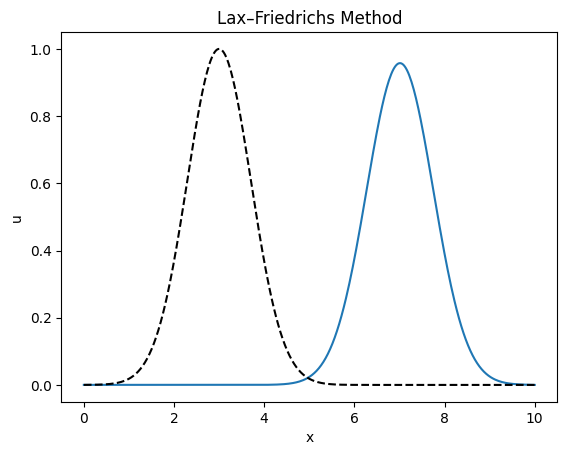

In [6]:
a = 3
N = 400
L = 10
dx = L / N
x = np.linspace(0, L, N)
u = np.exp(-(x-a)**2)
dt = 0.8 * dx / a   # satisfy CFL
steps = 200
u_init = u.copy()
k = a*dt/dx

for _ in range(steps):
    u_new = u.copy()
    for i in range(1, N-1):
        u_new[i] = (0.5*(u[i+1] + u[i-1]) - (k/2)*(u[i+1] - u[i-1]))
    u = u_new

plt.figure()
plt.plot(x, u)
plt.plot(x, u_init, 'k--')
plt.title("Lax–Friedrichs Method")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

# ✦ Lax–Wendroff scheme for Schrödinger equation

Given equation

$\qquad\qquad\displaystyle
i\hbar \frac{\partial \Psi}{\partial t} =-\frac{\hbar^2}{2m}\frac{\partial^2 \Psi}{\partial x^2}+ V(x)\Psi$

Rewriting

$\qquad\qquad\displaystyle \frac{\partial \Psi}{\partial t}=\alpha \Psi_{xx} + \beta \Psi$

where$\qquad\displaystyle\alpha = \frac{i\hbar}{2m}\, \quad \beta = -\frac{i}{\hbar}V(x)$

**Taylor expansion (Lax–Wendroff idea)**

$\qquad\qquad\displaystyle \Psi^{n+1}=\Psi^n + \Delta t\,\Psi_t^n + \frac{\Delta t^2}{2}\Psi_{tt}^n$

From PDE:

$\qquad\qquad\displaystyle \Psi_t = \alpha \Psi_{xx} + \beta \Psi$

$\qquad\qquad\displaystyle \Psi_{tt}= (\alpha \Psi_{xx} + \beta \Psi)_t=\alpha (\Psi_t)_{xx} + \beta \Psi_t$

Substitute again 

$\qquad\qquad\displaystyle \Psi_{tt}=\alpha^2 \Psi_{xxxx}+ 2\alpha\beta \Psi_{xx}+ \beta^2 \Psi$

Substitute into expansion

$\qquad\qquad\displaystyle \Psi^{n+1}=\Psi^n + \Delta t(\alpha \Psi_{xx} + \beta \Psi)+ \frac{\Delta t^2}{2}\left(\alpha^2 \Psi_{xxxx} + 2\alpha\beta\Psi_{xx} + \beta^2 \Psi \right)$

Finite difference form

$\qquad\qquad\displaystyle \Psi_{xx} \approx \frac{\Psi_{i+1}-2\Psi_i+\Psi_{i-1}}{\Delta x^2}$

$\qquad\qquad\displaystyle \Psi_{xxxx} \approx \frac{\Psi_{i+2}-4\Psi_{i+1}+6\Psi_i-4\Psi_{i-1}+\Psi_{i-2}}{\Delta x^4}$

Hence the **Lax–Wendroff scheme**:

$\qquad\qquad\displaystyle \Psi_i^{n+1}=\Psi_i^n+ \Delta t(\alpha D_2\Psi_i^n + \beta \Psi_i^n) + \frac{\Delta t^2}{2}  \left(\alpha^2 D_4\Psi_i^n + 2\alpha\beta D_2\Psi_i^n+ \beta^2 \Psi_i^n \right)$

##### ✦ Stability analysis (von Neumann)

Consider free particle $V=0$

$\qquad\qquad\displaystyle \Psi_t = \alpha \Psi_{xx}$

Assume Fourier mode:

$\qquad\qquad\displaystyle \Psi_i^n = G^n e^{ik i\Delta x}$

Using:

$\qquad\qquad\displaystyle D_2 \to -\frac{4}{\Delta x^2}\sin^2\left(\frac{k\Delta x}{2}\right),$                                                                      
$\qquad\qquad\displaystyle D_4 \to \;\;\frac{16}{\Delta x^4}\sin^4\left(\frac{k\Delta x}{2}\right)$

Substitute into scheme:

$\qquad\qquad\displaystyle G =1+ \Delta t \alpha (-\mu)+ \frac{\Delta t^2}{2} \alpha^2 (\mu^2)$

where $\qquad\quad\displaystyle \mu = \frac{4}{\Delta x^2}\sin^2\left(\frac{k\Delta x}{2}\right)$

So $\qquad\qquad\displaystyle G = 1 - \alpha \mu \Delta t + \frac{(\alpha \mu \Delta t)^2}{2}$

##### Magnitude of amplification factor

Since $\alpha = \frac{i\hbar}{2m}$ is imaginary $\qquad\qquad\displaystyle |G|^2 \neq 1$

# ✦ Stability conclusion

* The scheme is **not unitary**
* Probability is **not conserved**
* Errors grow with time

$\qquad\qquad\displaystyle \boxed{\text{Lax–Wendroff scheme is unstable/inappropriate for Schrödinger equation}}$


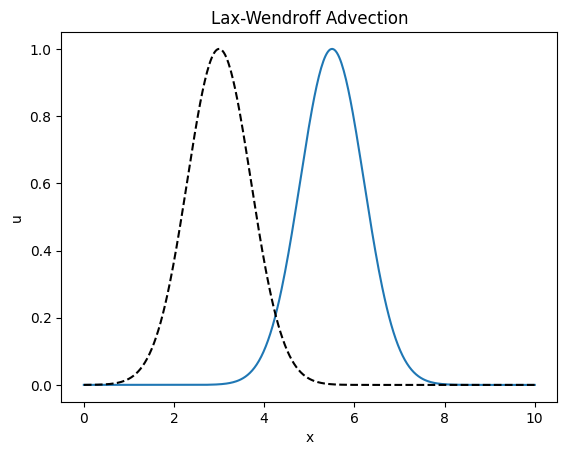

In [7]:
a = 3
N = 400
L = 10
dx = L / N
x = np.linspace(0, L, N)
u = np.exp(-(x-a)**2)
dt = 0.5 * dx / a   # CFL condition
steps = 200
u_init = u.copy()
k = a*dt/dx

for _ in range(steps):
    u_new = u.copy()
    for i in range(1, N-1):
        u_new[i] = (u[i] - (k/2)*(u[i+1] - u[i-1]) + (k**2/2)*(u[i+1] - 2*u[i] + u[i-1]))
    u = u_new

plt.figure()
plt.plot(x, u)
plt.plot(x, u_init, 'k--')
plt.title("Lax-Wendroff Advection")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

From Schrödinger equation, $\qquad\displaystyle i\hbar \frac{d\Psi}{dt} = H\Psi$

Rearrange,$\qquad\qquad\qquad\qquad\;\;\;\displaystyle \frac{d\Psi}{dt} = -\frac{i}{\hbar}H\Psi$

So,$\qquad\qquad\qquad\qquad\qquad\qquad\;\displaystyle A = -\frac{i}{\hbar}H$

#### 1. Explicit method (Forward Euler)

**Taylor expansion**

$\qquad\qquad\displaystyle \Psi(t+\Delta t) = \Psi(t) + \Delta t \frac{d\Psi}{dt} + O(\Delta t^2)$

$\qquad\qquad\displaystyle \Psi^{n+1} = \Psi^n + \Delta t\, A\Psi^n \qquad\qquad [\because \frac{d\Psi}{dt} = A\Psi ]$

$\qquad\qquad\displaystyle \Psi^{n+1} = (I + \Delta t A)\Psi^n$

$\qquad\qquad\displaystyle \Psi^{n+1}=\left(I - \frac{i\Delta t}{\hbar}H\right)\Psi^n \qquad\qquad [\because A = -\frac{i}{\hbar}H]$

**Analysis (why it fails)**

Compare with exact evolution:

$\qquad\qquad\displaystyle e^{-iH\Delta t/\hbar} = I - \frac{i\Delta t}{\hbar}H - \frac{\Delta t^2}{2\hbar^2}H^2 + \cdots$

Forward Euler keeps only the **first-order term**.

##### Norm check

Let $\qquad\qquad\quad\displaystyle U = I + \Delta t A$

$\qquad\qquad\qquad\displaystyle U^\dagger U \neq I$

* Not unitary
* Error: $O(\Delta t^2)$
* Can blow up (unstable)

#### 2. Implicit method (Backward Euler)

**Backward difference**

$\qquad\qquad\displaystyle\frac{\Psi^{n+1} - \Psi^n}{\Delta t} = A\Psi^{n+1}$

$\qquad\qquad\displaystyle \Psi^{n+1} - \Delta t A\Psi^{n+1} = \Psi^n$

$\qquad\qquad\displaystyle (I - \Delta t A)\Psi^{n+1} = \Psi^n$

$\qquad\qquad\displaystyle \Psi^{n+1} = (I - \Delta t A)^{-1}\Psi^n$

$\qquad\qquad\displaystyle \Psi^{n+1}=\left(I + \frac{i\Delta t}{\hbar}H\right)^{-1}\Psi^n  \qquad\qquad [\because A = -\frac{i}{\hbar}H]$


**Analysis**

Compare with exact exponential:

$\qquad\qquad\displaystyle (I - \Delta t A)^{-1}=I + \Delta t A + \Delta t^2 A^2 + \cdots$

* Also first-order accurate
* **Unconditionally stable**

##### Norm behavior

Let,  $\qquad\qquad\quad\displaystyle U = (I - \Delta t A)^{-1}$

Then, $\qquad\qquad\displaystyle U^\dagger U \neq I$

* Not unitary
* Causes **artificial damping** (wavefunction shrinks)

#### 3. Crank–Nicolson method 

Integrate over one step

$\qquad\qquad\displaystyle \Psi(t+\Delta t) = \Psi(t) + \int_t^{t+\Delta t} A\Psi(\tau)\,d\tau  \approx  \Psi(t) + \frac{\Delta t}{2}\left[A\Psi(t) + A\Psi(t+\Delta t)\right] \qquad\qquad [\because \text{trapezoidal rule}]$

$\qquad\qquad\displaystyle \Psi^{n+1} = \Psi^n + \frac{\Delta t}{2}\left(A\Psi^n + A\Psi^{n+1}\right)$

$\qquad\qquad\displaystyle \left(I - \frac{\Delta t}{2}A\right)\Psi^{n+1}=\left(I + \frac{\Delta t}{2}A\right)\Psi^n$

$\qquad\qquad\displaystyle \left(I + \frac{i\Delta t}{2\hbar}H\right)\Psi^{n+1}=\left(I - \frac{i\Delta t}{2\hbar}H\right)\Psi^n \qquad\qquad [\because A = -\frac{i}{\hbar}H]$

$\qquad\qquad\displaystyle \Psi^{n+1}=\left(I + \frac{i\Delta t}{2\hbar}H\right)^{-1} \left(I - \frac{i\Delta t}{2\hbar}H\right)\Psi^n$

**Analysis**

Let, $\qquad\qquad\;\;\displaystyle U = \left(I + \frac{i\Delta t}{2\hbar}H\right)^{-1} \left(I - \frac{i\Delta t}{2\hbar}H\right)$

Take adjoint (since $H^\dagger = H$),

$\qquad\qquad\qquad\displaystyle  U^\dagger =\left(I - \frac{i\Delta t}{2\hbar}H\right)^{-1} \left(I + \frac{i\Delta t}{2\hbar}H\right)$

Multiplying ,

$\qquad\qquad\displaystyle U^\dagger U = I$

* Norm conserved → **unitary evolution**
* Second-order accurate: error $O(\Delta t^3)$

<span style="color:red">Problem 5.15                                                                                                                                                     
Implement the explicit Euler method to solve the Schrödinger equation on $q=-\frac12$ to $\frac12$                                                            
(note, then, that $q_j = j\Delta x − \frac12$, we’ll assume that the wave function vanishes at the endpoints $-\frac12$ and $\frac12$) with                
$\qquad\qquad\displaystyle V(q) =\begin{cases}0, & q \le \frac{1}{8} \\ 5000, & q > \frac{1}{8} \end{cases} \qquad\qquad(5.86)$                                  
Use, for $\chi(q, 0)$, the Gaussian in (5.34) rendered dimensionless, as in (5.75), with
constants $\tilde{E} = 4500, \tilde{p} = 100, \Delta q = \frac{1}{201}$                                                                                     
(so $N = 200$ grid points extending from $−\frac12 + \Delta q$ to $\frac12 - \Delta q$) and $\Delta s = \frac{\Delta q}{2000}$.                             
You should check that in the zero potential case, you get a wave function that is expanding and moving to the right (take, say, 500 steps).

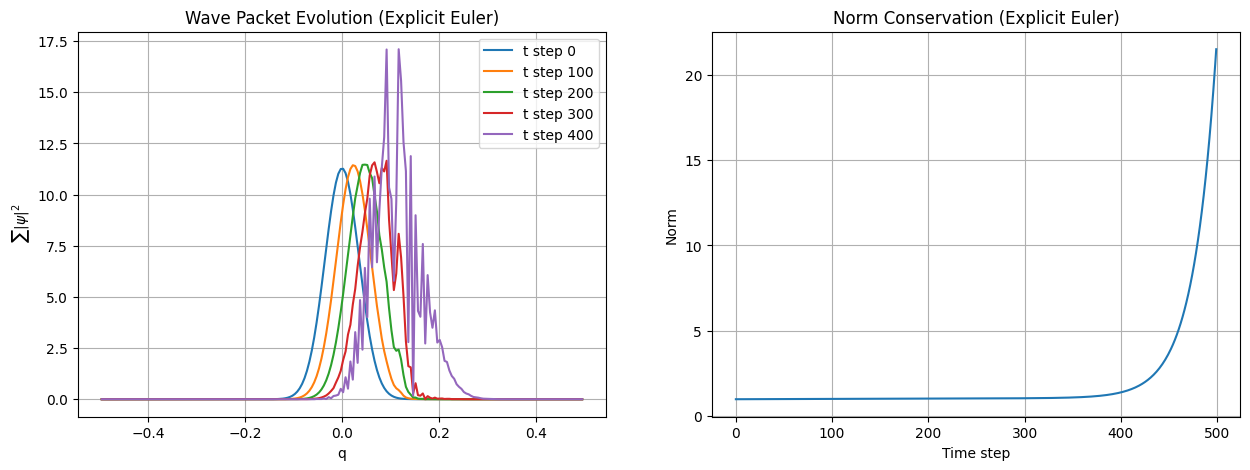

In [8]:
hbar = 1.0
m    = 1.0
N  = 200
dq = 1/201
q  = np.linspace(-0.5 + dq, 0.5 - dq, N)
ds = dq / 2000
V = np.zeros(N)
V[q > 1/8] = 5000
E_tilde = 4500
p_tilde = 100
q0    =  0            # initial center (left side)
sigma = 0.05               # width
psi = np.exp(-(q - q0)**2 / (2*sigma**2)) * np.exp(1j * p_tilde * q)
psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dq)
 
def laplacian(psi):
    d2 = np.zeros_like(psi, dtype=complex)
    d2[1:-1] = (psi[2:] - 2*psi[1:-1] + psi[:-2]) / dq**2
    return d2
 
steps = 500
snapshots = []
norms = []
for n in range(steps):
    norm = np.sum(np.abs(psi)**2) * dq
    norms.append(norm)
    d2psi = laplacian(psi)
    rhs = -1j * ( -0.5 * d2psi + V * psi )
    psi = psi + ds * rhs
    psi[0]  = 0
    psi[-1] = 0
    if n % 100 == 0:
        snapshots.append(np.abs(psi)**2)

plt.figure(figsize=(15,5))
plt.subplot(121)
for i, prob in enumerate(snapshots):
    plt.plot(q, prob, label=f"t step {i*100}")
plt.xlabel("q")
plt.ylabel(r" $\sum |\psi|^2$")
plt.title("Wave Packet Evolution (Explicit Euler)")
plt.legend()
plt.grid()
#plt.show()

plt.subplot(122)
plt.plot(norms)
plt.xlabel("Time step")
plt.ylabel("Norm")
plt.title("Norm Conservation (Explicit Euler)")
plt.grid()
plt.show()

<span style="color:red">Problem 5.16                                                                                                                                                 
Implement the implicit Euler method, and solve the same problem as above.

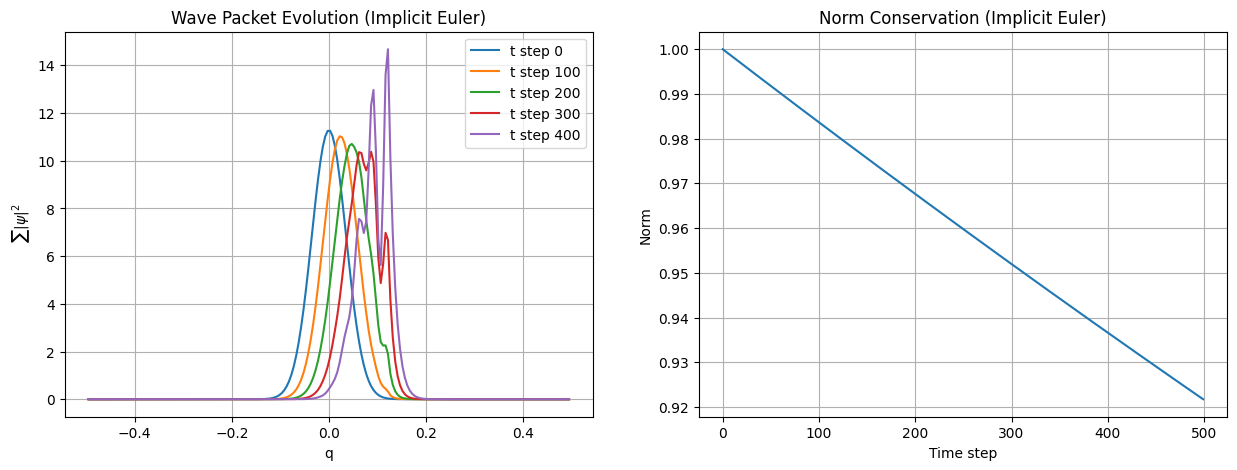

In [9]:
hbar = 1.0
m    = 1.0
N  = 200
dq = 1/201
q  = np.linspace(-0.5 + dq, 0.5 - dq, N)
ds = dq / 2000
V = np.zeros(N)
V[q > 1/8] = 5000   # barrier
p_tilde = 100
q0    = 0
sigma = 0.05
psi = np.exp(-(q - q0)**2 / (2*sigma**2)) * np.exp(1j * p_tilde * q)
psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dq)
H = np.zeros((N, N), dtype=complex)
for i in range(N):
    H[i, i] = 1.0 / dq**2 + V[i]   # diagonal
    if i > 0:
        H[i, i-1] = -0.5 / dq**2
    if i < N-1:
        H[i, i+1] = -0.5 / dq**2
I = np.eye(N, dtype=complex)
A = I + 1j * ds * H
steps = 500
snapshots = []
norms = []
for n in range(steps):
    norm = np.sum(np.abs(psi)**2) * dq
    norms.append(norm)
    psi = np.linalg.solve(A, psi)
    psi[0]  = 0
    psi[-1] = 0
    if n % 100 == 0:
        snapshots.append(np.abs(psi)**2)

plt.figure(figsize=(15,5))
plt.subplot(121)
for i, prob in enumerate(snapshots):
    plt.plot(q, prob, label=f"t step {i*100}")
plt.xlabel("q")
plt.ylabel(r" $\sum |\psi|^2$")
plt.title("Wave Packet Evolution (Implicit Euler)")
plt.legend()
plt.grid()
#plt.show()

plt.subplot(122)
plt.plot(norms)
plt.xlabel("Time step")
plt.ylabel("Norm")
plt.title("Norm Conservation (Implicit Euler)")
plt.grid()
plt.show()

<span style="color:red">Problem 5.17                                                                                                                                                       
The Crank–Nicolson method is a kind of average of the implicit and explicit Euler methods.                                                                  
Referring to (5.61), we could write the explicit Euler update as:                                                                                                  
$\qquad\qquad\displaystyle \frac{\psi^{n+1} - \psi^n}{\Delta s} = -i \mathbb{H} \psi^n \tag{5.87}$                                                               
for $\mathbb{H}$ the discretized Hamiltonian operator.                                                                                                                     
The implicit update comes from:                                                                                                                                    
$\qquad\qquad\displaystyle\frac{\psi^{n+1} - \psi^n}{\Delta s} = -i \mathbb{H} \psi^{n+1} \tag{5.88}$                                                            
To get Crank–Nicolson, we take:                                                                                                                                 
$\qquad\qquad\displaystyle\frac{\psi^{n+1} - \psi^n}{\Delta s} = -i \mathbb{H} \left(\frac{\psi^{n+1} + \psi^n}{2}\right)\tag{5.89}$                                      
                                                                                                                                                        Separating the dependence on $\psi^{n+1}$ and $\psi^n$, we have:                                                                                                              
$\qquad\qquad\displaystyle\underbrace{\left(\mathbb{I} + \frac{i \Delta s}{2} \mathbb{H} \right)}_{\equiv \ \mathbb{\bar{P}} }\;\psi^{n+1}=
\left(\mathbb{I} - \frac{i \Delta s}{2} \mathbb{H} \right)\psi^n \tag{5.90}$                                                                               
Implement the method, and solve the step problem again.

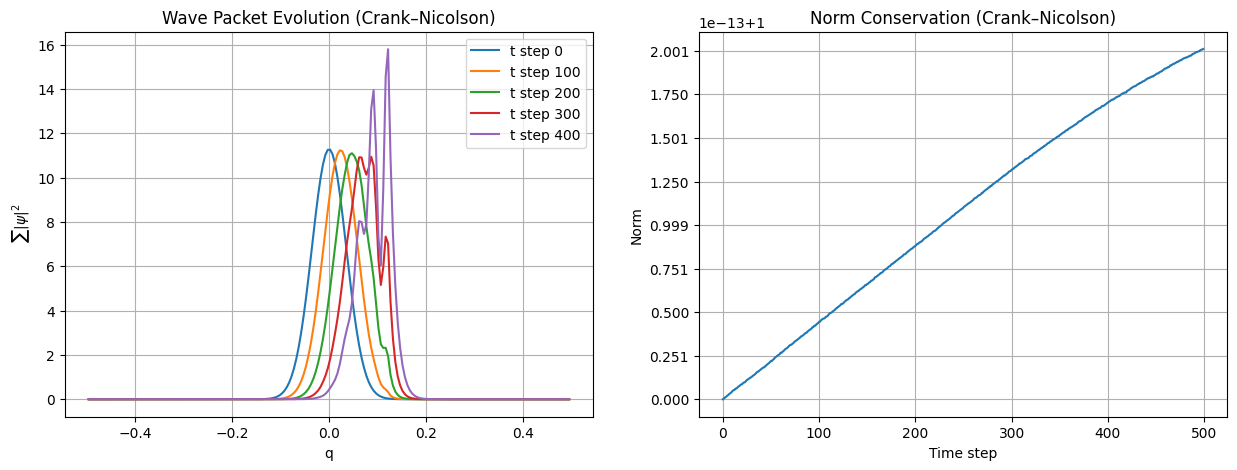

In [10]:
hbar = 1.0
m    = 1.0
N  = 200
dq = 1/201
q  = np.linspace(-0.5 + dq, 0.5 - dq, N)
ds = dq / 2000
V = np.zeros(N)
V[q > 1/8] = 5000   # step potential
p_tilde = 100
q0    = 0
sigma = 0.05
psi = np.exp(-(q - q0)**2 / (2*sigma**2)) * np.exp(1j * p_tilde * q)
psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dq)
H = np.zeros((N, N), dtype=complex)
for i in range(N):
    H[i, i] = 1.0 / dq**2 + V[i]
    if i > 0:
        H[i, i-1] = -0.5 / dq**2
    if i < N-1:
        H[i, i+1] = -0.5 / dq**2
I = np.eye(N, dtype=complex)
A = I + 1j * ds * H / 2   # left-hand side
B = I - 1j * ds * H / 2   # right-hand side
steps = 500
snapshots = []
norms = []
for n in range(steps):
    norm = np.sum(np.abs(psi)**2) * dq
    norms.append(norm)
    rhs = B @ psi
    psi = np.linalg.solve(A, rhs)
    psi[0]  = 0
    psi[-1] = 0
    if n % 100 == 0:
        snapshots.append(np.abs(psi)**2)
 
plt.figure(figsize=(15,5))
plt.subplot(121)
for i, prob in enumerate(snapshots):
    plt.plot(q, prob, label=f"t step {i*100}")
plt.xlabel("q")
plt.ylabel(r" $\sum |\psi|^2$")
plt.title("Wave Packet Evolution (Crank–Nicolson)")
plt.legend()
plt.grid()
#plt.show()

plt.subplot(122)
plt.plot(norms)
plt.xlabel("Time step")
plt.ylabel("Norm")
plt.title("Norm Conservation (Crank–Nicolson)")
plt.grid()
plt.show()

<span style="color:red">Problem 5.18                                                                                                                                              
Your wave function has some initial normalization (from our current point of view, it doesn’t much matter what its value is, although ideally, it should be 1):                                                                                                                                                     
 $\qquad\qquad\displaystyle \int_0^1 \psi^*(s, q)\,\psi(s, q)\,dq = A \tag{5.91}$                                                                         
Schrödinger equation respects this normalization (so that $\psi(x, t )$ solving it has constant normalization).                                               
Your numerical methods will not, in general. Take the following, plausible (our next subject is precisely integration), approximation to the integral in (5.91):                                                                                                                                                   
$\qquad\qquad\displaystyle\sum_{j=1}^{200} ||\psi_j^n||^2 \, \Delta q \tag{5.92}$

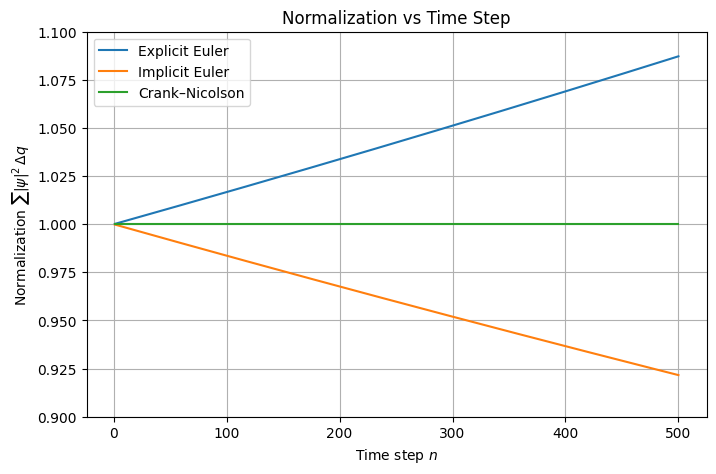

In [11]:
N  = 200
dq = 1/201
q  = np.linspace(-0.5 + dq, 0.5 - dq, N)
ds = dq / 2000
steps = 500
V = np.zeros(N)
V[q > 1/8] = 5000
p_tilde = 100
q0    = -0.25
sigma = 0.05
psi0 = np.exp(-(q - q0)**2 / (2*sigma**2)) * np.exp(1j * p_tilde * q)
psi0 = psi0 / np.sqrt(np.sum(np.abs(psi0)**2) * dq)
H = np.zeros((N, N), dtype=complex)

for i in range(N):
    H[i, i] = 1.0 / dq**2 + V[i]
    if i > 0:
        H[i, i-1] = -0.5 / dq**2
    if i < N-1:
        H[i, i+1] = -0.5 / dq**2

I = np.eye(N, dtype=complex)
norm_explicit = []
norm_implicit = []
norm_cn       = []
psi_explicit = psi0.copy()
psi_implicit = psi0.copy()
psi_cn       = psi0.copy()

# Precompute CN matrices
A_cn = I + 1j * ds * H / 2
B_cn = I - 1j * ds * H / 2

# Precompute implicit matrix
A_impl = I + 1j * ds * H
 
for n in range(steps):

    # ----- Explicit Euler -----
    rhs_exp = -1j * (H @ psi_explicit)
    psi_explicit = psi_explicit + ds * rhs_exp
    psi_explicit[0]  = 0
    psi_explicit[-1] = 0
    norm_explicit.append(np.sum(np.abs(psi_explicit)**2) * dq)

    # ----- Implicit Euler -----
    psi_implicit = np.linalg.solve(A_impl, psi_implicit)
    psi_implicit[0]  = 0
    psi_implicit[-1] = 0
    norm_implicit.append(np.sum(np.abs(psi_implicit)**2) * dq)

    # ----- Crank–Nicolson -----
    rhs_cn = B_cn @ psi_cn
    psi_cn = np.linalg.solve(A_cn, rhs_cn)
    psi_cn[0]  = 0
    psi_cn[-1] = 0
    norm_cn.append(np.sum(np.abs(psi_cn)**2) * dq)
 
plt.figure(figsize=(8,5))
plt.plot(range(1, steps+1), norm_explicit, label="Explicit Euler")
plt.plot(range(1, steps+1), norm_implicit, label="Implicit Euler")
plt.plot(range(1, steps+1), norm_cn, label="Crank–Nicolson")
plt.xlabel(r"Time step $n$")
plt.ylabel(r"Normalization $\sum |\psi|^2 \, \Delta q$")
plt.title("Normalization vs Time Step")
plt.legend()
plt.grid()
plt.ylim(0.9, 1.1)
plt.show()

<span style="color:red">Problem 5.19                                                                                                                                                   
Implement the **Crank–Nicolson** solution for **Schrödinger** equation in two dimensions –                                                                                
the update will look like (5.90), but this time the matrix $\mathbb{H}$ includes the Laplacian matrix approximation within it.                                           
In terms of the matrices $\mathbb{D}$ and $\mathbb{\tilde{V}}$ from (5.68), we have                                                                                                            
$\qquad\qquad\displaystyle \underbrace{\left(\mathbb{I} + \frac{i \Delta s}{2}(-\mathbb{D} + \mathbb{\tilde{V}})\right)}_{\equiv \ \mathbb{\bar{P}} }\;\psi^{n+1}=\left(\mathbb{I} - \frac{i \Delta s}{2}(-\mathbb{D} + \mathbb{\tilde{V}})\right)\psi^n \tag{5.93}$                                           
Now write a function that performs the update $\psi^{n+1} = \mathbb{\bar{P}^{-1}\bar{P}^∗} \psi^n$ by first forming the product $\mathbb{\bar{P}^∗}\psi^n$,                            
and then doing the matrix inversion using the built-in function LinearSolve.                                                                               
Your function should take in the initial wave function and the number of temporal steps to take (along with $\Delta s$) in addition to the matrix $\mathbb{\bar{P}}$.                                                                                                                                                
The solutions will be embedded in the usual rectangular manner from Section 4.3 and                                                                        
you can make contour or three-dimensional plots of the probability densities to generate movies.                                                              
As a problem for testing, take a $25\times 25$ grid with $\Delta q = \Delta r = \frac{1}{26}$ ($q$ and $r$ are the scaled spatial variables),                
a finite circular well potential $\qquad\displaystyle V(q, r) = \begin{cases} -1000, & (q - \tfrac{1}{2})^2 + (r - \tfrac{1}{2})^2 \le 0.1 \\ 0, & \text{otherwise} \end{cases}\tag{5.94}$                                                                                                                            
and initial wave function :                                                                                                                                    
$\qquad\qquad\displaystyle \psi^0(q, r) = \left(\frac{2}{\pi}\right)^{\frac14} \left(\tilde{E} - \frac{\tilde{p}^2}{4}\right)^{\frac14} e^{-(\tilde{E} - \frac{\tilde{p}^2}{4})(q - \frac14)^2} e^{i \frac{\tilde{p}}{2} (q - \frac12)}\times\left(\frac{2}{\pi}\right)^{\frac14} \left(\tilde{E} - \frac{\tilde{p}^2}{4}\right)^{\frac14} e^{-(\tilde{E} - \frac{\tilde{p}^2}{4})(r - \frac12)^2} \tag{5.95}$                                                                                                    
a Gaussian centered at $q = \frac14, r = \frac12$ and with momentum in the $q$ direction initially – take $\tilde{E} = 450, \tilde{p} = 40$ and $\Delta s = 0.001$.                                                                                                                                               
Run the solution for 10 steps and make a movie of the result – check that the norm of the probability density is relatively constant over this range         
(use simple rectangular sums to approximate the integrals as in (5.92)).


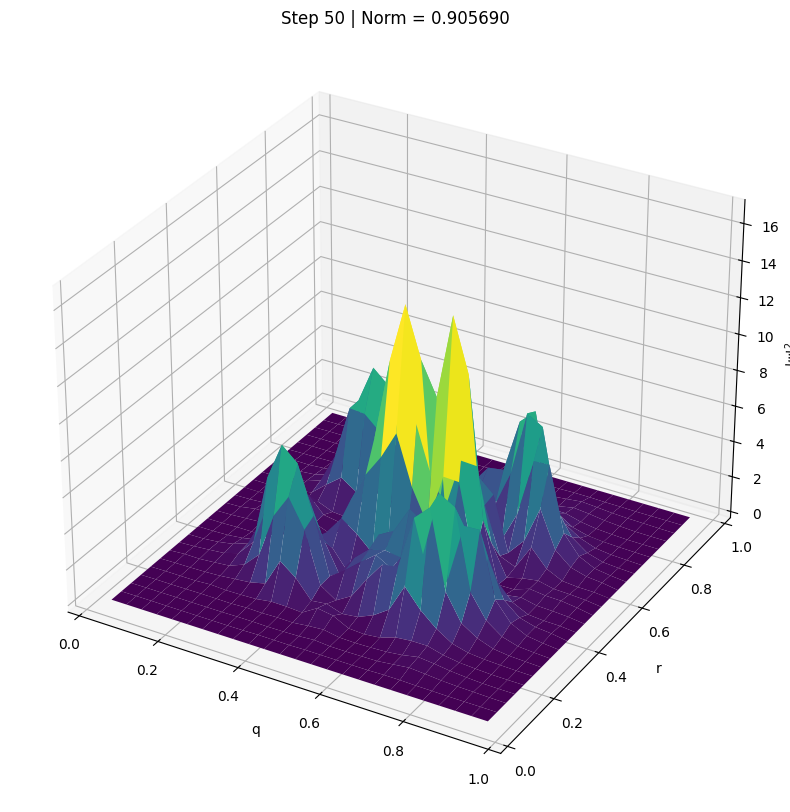

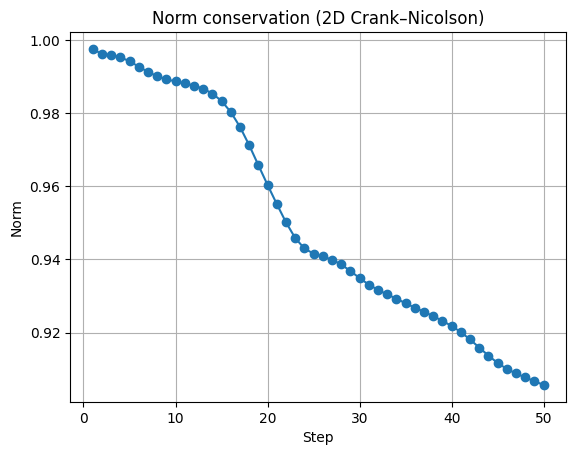

In [12]:
N       = 25
dq      = 1/26   
x       = np.linspace(dq, 1 - dq, N)
y       = np.linspace(dq, 1 - dq, N)
X, Y    = np.meshgrid(x, y, indexing='ij')
ds      = 0.001
steps   = 50
E_tilde = 450
p_tilde = 40

V       = np.zeros((N, N))
mask    = (X - 0.5)**2 + (Y - 0.5)**2 <= 0.1
V[mask] = -1000
V_flat  = V.flatten()

D1 = np.zeros((N, N))
for i in range(N):
    D1[i, i] = -2
    if i > 0:
        D1[i, i-1] = 1
    if i < N-1:
        D1[i, i+1] = 1
D1 = D1 / dq**2
I1 = np.eye(N)
D  = np.kron(D1, I1) + np.kron(I1, D1)
H  = -D + np.diag(V_flat)
I  = np.eye(N*N, dtype=complex)
P_bar  = I + 1j * ds/2 * H
P_star = I - 1j * ds/2 * H
alpha  = E_tilde - p_tilde**2 / 4

psi = ((2/np.pi)**0.25 * alpha**0.25 * np.exp(-alpha * (X - 0.25)**2) * np.exp(1j * 0.5 * p_tilde * (X - 0.5))) * \
      ((2/np.pi)**0.25 * alpha**0.25 * np.exp(-alpha * (Y - 0.5)**2))
psi = psi.flatten()
psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dq * dq)
norms = []

for n in range(steps):
    psi_2d = psi.reshape(N, N)
    psi_2d [0, :] = 0
    psi_2d[-1, :] = 0
    psi_2d[ :, 0] = 0
    psi_2d[ :,-1] = 0
    psi = psi_2d.flatten()
    prob = np.abs(psi_2d)**2    # Probability density
    norm = np.sum(prob) * dq * dq
    norms.append(norm)

    clear_output(wait=True)
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, prob, cmap='viridis', edgecolor='none')
    ax.set_zlim(0, np.max(prob)*1.2)
    ax.set_title(f"Step {n+1} | Norm = {norm:.6f}")
    ax.set_xlabel("q")
    ax.set_ylabel("r")
    ax.set_zlabel(r"$|\psi|^2$")
    #ax.axis('off')
    plt.show()

    b = P_star @ psi
    psi = np.linalg.solve(P_bar, b)

plt.figure()
plt.plot(range(1, steps+1), norms, marker='o')
plt.title("Norm conservation (2D Crank–Nicolson)")
plt.xlabel("Step")
plt.ylabel("Norm")
plt.grid()
plt.show()

<span style="color:red">Problem 10.7                                                                                                                                                    
a) Find $p$ in                                                                                                                                                      
$\qquad\displaystyle \psi''(x_j ) = \frac{\psi(x_{j+1}) − 2\psi(x_j ) + ψ(x_{j−1})}{\Delta x^2} + O(\Delta x^p),  \qquad\qquad (10.85)$                                                                                                                                                       
from (10.24) with the error in place.                                                                                                                      
b) We could use a more accurate approximation to $\psi''$.                                                                                                                                                                                                                                                      Find the coefficients $a$ and $b$ in                                                                                                                                                     
$\qquad\displaystyle  \psi''(x_j ) = \frac{a\psi(x_{j+2}) + b\psi(x_{j+1}) − 2(a + b)\psi(x_j ) + b\psi(x_{j−1}) + a\psi(x_{j−2})}{\Delta x^2}+O(\Delta x^4).  \qquad\qquad (10.86)$                                                                                                                                                     
This approximation requires more boundary data.

### (a) Order of accuracy $p$

Using Taylor expansion about $x_j$

$\qquad\qquad\qquad\displaystyle 
\psi(x_{j\pm1}) = \psi(x_j) \pm \Delta x,\psi'(x_j) + \frac{\Delta x^2}{2}\psi''(x_j) \pm \frac{\Delta x^3}{6}\psi'''(x_j) + \frac{\Delta x^4}{24}\psi^{(4)}(x_j) + \cdots$

Substitute into (10.85):

$\qquad\qquad\qquad\displaystyle
\frac{\psi(x_{j+1}) - 2\psi(x_j) + \psi(x_{j-1})}{\Delta x^2}$

Odd-derivative terms cancel, giving 

$\qquad\qquad\qquad\displaystyle
= \psi''(x_j) + \frac{\Delta x^2}{12}\psi^{(4)}(x_j) + O(\Delta x^4)$

So the leading error is $O(\Delta x^2)$.                                                                                                                   
**Hence, $p = 2$.**

 
### (b) Higher-order approximation

We expand all terms 

$\qquad\qquad\qquad\displaystyle
\psi(x_{j\pm1}), \quad \psi(x_{j\pm2})$

$\qquad\qquad\qquad\displaystyle
\psi(x_{j\pm2}) = \psi(x_j) \pm 2\Delta x,\psi' + 2\Delta x^2\psi'' \pm \frac{4}{3}\Delta x^3\psi''' + \frac{2}{3}\Delta x^4\psi^{(4)} + \cdots$

Now plug into

$\qquad\qquad\qquad\displaystyle
\frac{a\psi_{j+2} + b\psi_{j+1} - 2(a+b)\psi_j + b\psi_{j-1} + a\psi_{j-2}}{\Delta x^2}$

Collect terms:

* Coefficient of $\psi(x_j)$: cancels automatically.
* Coefficient of $\psi'(x_j)$: cancels by symmetry.
* Coefficient of $\psi''(x_j)$: $\quad\displaystyle 2a(2^2) + 2b(1^2) = 8a + 2b$

After dividing by $\Delta x^2$, we need:

$\qquad\qquad\qquad\displaystyle 8a + 2b = 2 \quad \Rightarrow \quad 4a + b = 1 \quad (1)$

* Coefficient of $\psi^{(4)}(x_j)$ 

$\qquad\qquad\qquad\displaystyle 
2a\left(\frac{2^4}{24}\right) + 2b\left(\frac{1^4}{24}\right)
= 2a\left(\frac{16}{24}\right) + 2b\left(\frac{1}{24}\right)
= \frac{4a}{3} + \frac{b}{12}$

For $O(\Delta x^4)$, this must vanish:

$\qquad\qquad\qquad\displaystyle \frac{4a}{3} + \frac{b}{12} = 0
\quad \Rightarrow \quad 16a + b = 0 \quad (2)$

Solve (1) and (2):

$\qquad\qquad\qquad\displaystyle 4a + b = 1$

$\qquad\qquad\qquad\displaystyle 16a + b = 0$

Subtract 

$\qquad\qquad\qquad\displaystyle 12a = -1 \Rightarrow a = -\frac{1}{12}$

Then

$\qquad\qquad\qquad\displaystyle b = 1 - 4a = 1 + \frac{1}{3} = \frac{4}{3}$

Thus 

$\qquad\qquad\qquad\displaystyle \boxed{a = -\frac{1}{12}, \quad b = \frac{4}{3}}$

This gives a **fourth-order accurate** approximation $O(\Delta x^4)$.


<span style="color:red">Problem 10.8                                                                                                                                                   
In the case of the infinite square well, with $−\psi''(q) = E\tilde{ψ}(q)$,                                                                               
we can find the discretized eigenvalues exactly, and compare those with the known energy spectrum $\tilde{E} = n^2\pi^2$.                                                                                                                
Take $\psi(q) = Ae^{i\pi kq}$ for integer $k$. Now discretize using $q_j = j\Delta q$, so that: $\psi_j = Ae^{i\pi kj\Delta  q}$ .                               
Insert this directly in the discretized form :                                                                                                            
$\qquad\qquad\qquad\displaystyle \frac{−\psi_{j+1} + 2\psi_j − \psi_{j−1}}{\Delta q^2} = \lambda_k\psi_j \qquad\qquad(10.87)$                                              
and find the eigenvalues (indexed by $k$).                                                                                                                            
Subtract the continuous solution, $k^2\pi^2$ and Taylor expand this residual for $\Delta q\rightarrow 0$.                                                    
What is the size of the leading error in your discrete approximation to the energy spectrum for a particle in a box ?                                        
For what value $k$ is the size of this error of the same order as the “dominant” $k^2\pi^2$ term (write in terms of $\Delta q$) ?                          
For what $k$ is the error order one?

Start from  

$\qquad\qquad\qquad\displaystyle\psi_j = A e^{i\pi k j \Delta q}$

Insert into (10.87):

$\qquad\qquad\qquad\displaystyle\frac{-\psi_{j+1} + 2\psi_j - \psi_{j-1}}{\Delta q^2}= \lambda_k \psi_j$

Compute shifts:

$\qquad\qquad\qquad\displaystyle\psi_{j\pm1} = \psi_j e^{\pm i\pi k \Delta q}$

So,

$\qquad\qquad\qquad\displaystyle\lambda_k
= \frac{-e^{i\pi k \Delta q} + 2 - e^{-i\pi k \Delta q}}{\Delta q^2}
= \frac{2 - 2\cos(\pi k \Delta q)}{\Delta q^2}$

Use identity:

$\qquad\qquad\qquad\displaystyle
\lambda_k = \frac{4 \sin^2\left(\frac{\pi k \Delta q}{2}\right)}{\Delta q^2}$

 
#### Compare with continuum

Exact energy:

$\qquad\qquad\qquad\displaystyle E_k = \pi^2 k^2$

Now expand for small $\Delta q$,

$\qquad\qquad\qquad\displaystyle 
\sin\left(\frac{\pi k \Delta q}{2}\right)
= \frac{\pi k \Delta q}{2} - \frac{1}{6}\left(\frac{\pi k \Delta q}{2}\right)^3 + \cdots$

So,

$\qquad\qquad\qquad\displaystyle \lambda_k= \pi^2 k^2 - \frac{\pi^4 k^4}{12}\Delta q^2 + O(\Delta q^4)$

 
#### Residual (error)

$\qquad\qquad\qquad\displaystyle\lambda_k - \pi^2 k^2
= - \frac{\pi^4 k^4}{12}\Delta q^2 + O(\Delta q^4)$

**Leading error size:**

$\qquad\qquad\qquad\displaystyle\boxed{O(k^4 \Delta q^2)}$

**When is error comparable to main term ?**

Compare:

$\qquad\qquad\qquad\displaystyle
k^4 \Delta q^2 \sim k^2
\Rightarrow k^2 \Delta q^2 \sim 1
\Rightarrow k \sim \frac{1}{\Delta q}$

**When is error order 1 ?**

$\qquad\qquad\qquad\displaystyle
k^4 \Delta q^2 \sim 1
\Rightarrow k \sim \frac{1}{\sqrt{\Delta q}}$


<span style="color:red">Problem 10.9                                                                                                                                                  
Using (10.77), find the perturbed energies for an infinite square well (extending from $q = 0$ to $1$) with a perturbed bottom, $\tilde{V}(q) = −\epsilon q$.                                                                                                                                                  
This perturbation comes from a constant force acting on a particle confined to the well. An example would be gravity near the surface of the Earth.

Use first–order perturbation theory (your eq. 10.77):

$\qquad\qquad\qquad\displaystyle E_n^{(1)}=\langle \psi_n | \tilde V | \psi_n\rangle$

For the infinite well on $0\le q\le 1$,

$\qquad\qquad\qquad\displaystyle\psi_n(q)=\sqrt{2}\sin(n\pi q)\, \qquad E_n^{(0)}=n^2\pi^2$

Perturbation

$\qquad\qquad\qquad\displaystyle \tilde V(q)=-\epsilon q$


##### First-order shift

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = -\epsilon \int_0^1 2\sin^2(n\pi q)\, q\, dq$

Use

$\qquad\qquad\qquad\displaystyle\sin^2(n\pi q)=\frac{1-\cos(2n\pi q)}{2}$

So

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = -\epsilon \int_0^1 q(1-\cos(2n\pi q))\, dq$

Split

$\qquad\qquad\qquad\displaystyle \int_0^1 q\,dq = \frac{1}{2}$

$\qquad\qquad\qquad\displaystyle \int_0^1 q\cos(2n\pi q)\,dq = 0$

$($boundary terms cancel since $ \displaystyle\sin(2n\pi)=0\,\ \cos(2n\pi)=1)$

Thus

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = -\epsilon \cdot \frac{1}{2}$

$\qquad\qquad\qquad\displaystyle \boxed{E_n = n^2\pi^2 - \frac{\epsilon}{2} + O(\epsilon^2)}$

##### Interpretation

All energy levels shift **down by the same amount** $\displaystyle -\frac{\epsilon}{2}$

Physically: a constant force tilts the well, but to first order it only shifts the entire spectrum uniformly (no change in level spacing).


<span style="color:red">Problem 10.10                                                                                                                                                 
Work out the energy spectrum to first order for an infinite square well (from $0\rightarrow 1$) with perturbing potential : $\tilde{V}(q) = \epsilon\sin(\pi q)$.

Use first-order perturbation theory:

$\qquad\qquad\qquad\displaystyle E_n^{(1)}=\langle \psi_n|\tilde V|\psi_n\rangle$

For the well $0\le q\le 1$

$\qquad\qquad\qquad\displaystyle \psi_n(q)=\sqrt{2}\sin(n\pi q), \qquad E_n^{(0)}=n^2\pi^2$

Perturbation

$\qquad\qquad\qquad\displaystyle \tilde V(q)=\epsilon \sin(\pi q)$

##### First-order shift

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = 2\epsilon \int_0^1 \sin^2(n\pi q)\,\sin(\pi q)\,dq$

Use

$\qquad\qquad\qquad\displaystyle \sin^2(n\pi q)=\frac{1-\cos(2n\pi q)}{2}$

So

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = \epsilon \int_0^1 \sin(\pi q)\,dq - \epsilon \int_0^1 \cos(2n\pi q)\sin(\pi q)\,dq$
  

##### Evaluate terms

First term

$\qquad\qquad\qquad\displaystyle \int_0^1 \sin(\pi q)\,dq = \frac{2}{\pi}$

Second term (use trig identity)

$\qquad\qquad\qquad\displaystyle \cos A \sin B = \tfrac{1}{2}[\sin(B+A)+\sin(B-A)]$

Gives

$\qquad\qquad\qquad\displaystyle \int_0^1 \cos(2n\pi q)\sin(\pi q)\,dq
= \frac{1}{2}\left[\frac{2}{(2n+1)\pi} + \frac{2}{(1-2n)\pi}\right]
= \frac{1}{\pi}\left(\frac{1}{1+2n}+\frac{1}{1-2n}\right) = \frac{2}{\pi(1-4n^2)}$


##### Final shift

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = \frac{2\epsilon}{\pi} - \epsilon \cdot \frac{2}{\pi(1-4n^2)}$

$\qquad\qquad\qquad\displaystyle E_n^{(1)} = \frac{2\epsilon}{\pi}\left[1 - \frac{1}{1-4n^2}\right]
= \frac{2\epsilon}{\pi}\cdot \frac{4n^2}{4n^2-1}$

$\qquad\qquad\qquad\displaystyle\boxed{E_n = n^2\pi^2 + \frac{8\epsilon n^2}{\pi(4n^2-1)} + O(\epsilon^2)}$

##### Insight

* Unlike Problem 10.9, the shift **depends on (n)**.
* Higher levels ((n\to\infty)) approach a constant shift $\quad\displaystyle   E_n^{(1)} \to \frac{2\epsilon}{\pi}$


<span style="color:red">Problem 10.14                                                                                                                                            
Discretize the Schr¨odinger equation with the harmonic oscillator potential as written in (10.84).                                                         
Take $q_{\infty} = 10,$ and discretize using $q_j = −q_{\infty} + j\Delta q$ with $\Delta q = \frac{2q_{\infty}}{N+1}$ and $N = 100$.                         
(a) Find the eigenvalues and eigenvectors of the discretized matrix on the left of (10.84)                                                                   
using the QR method you implemented in the previous problem with $M = 500$ (i.e. set a maximum of five hundred iterations).                                                                                                            
Plot the exact energies from Problem 10.6 for $n = 1$ to $50$ together with the first fifty (smallest to largest) eigenvalues determined by the QR method.                                                                                                                                                        
At what $n$, roughly, do you begin to diverge from the exact energies (i.e. where do you lose the linear form of the exact solution) ?                                
(b) Plot the first and tenth $n = 0, n = 9$ eigenvectors, determined numerically, as points, with the exact solutions on top.                            
You must normalize your numerical eigenvectors to match the quantum mechanical normalization,                                                               
which in discrete (approximate) form, reads : $\displaystyle\sum_{j=1}^N |\psi_j|^2\Delta q = 1$ (i.e. divide your eigenvectors by $\sqrt{\Delta q}$ ).                                                          
Given that you have implicitly put the oscillator potential inside an infinite square well, can you see why,                                                 
from the wave functions, the eigenvalues begin to diverge from the linear exact form?

Matrix:

$\qquad\qquad\qquad\displaystyle H = -\frac{1}{\Delta q^2}
\begin{pmatrix}
-2 & 1 & 0 & \cdots \\
1 & -2 & 1 & \cdots \\
0 & 1 & -2 & \cdots \\
\vdots & & & \ddots
\end{pmatrix} + \text{diag}(q_j^2)$

(assuming units with $\hbar=\omega=m=1$, so $V=q^2$).

In [15]:
N = 100
q_inf = 10
dq = 2*q_inf/(N+1)

q = np.linspace(-q_inf + dq, q_inf - dq, N)

# kinetic
D = -2*np.eye(N)
for i in range(N-1):
    D[i, i+1] = 1
    D[i+1, i] = 1
D = D / dq**2

# potential
V = np.diag(q**2)

H = -D + V

In [16]:
def qr_eigen(A, M=500):
    A_k = A.copy()
    Q_total = np.eye(A.shape[0])

    for _ in range(M):
        Q, R = np.linalg.qr(A_k)
        A_k = R @ Q
        Q_total = Q_total @ Q

    return np.diag(A_k), Q_total

In [17]:
E_qr, psi_qr = qr_eigen(H, M=500)

# sort
idx = np.argsort(E_qr)
E_qr = E_qr[idx]
psi_qr = psi_qr[:, idx]

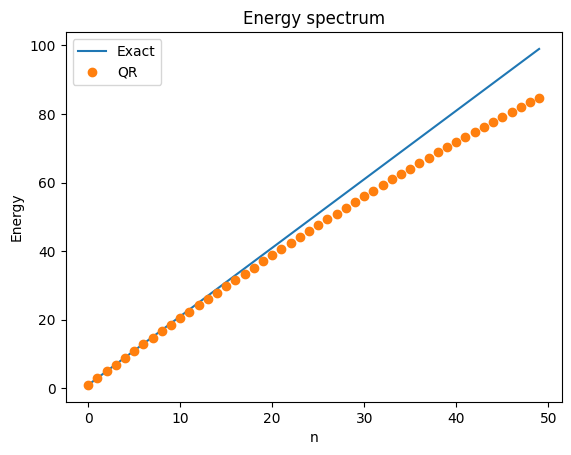

In [18]:
n = np.arange(0, 50)
E_exact = 2*n + 1

plt.figure()
plt.plot(n, E_exact, label="Exact")
plt.plot(n, E_qr[:50], 'o', label="QR")
plt.xlabel("n")
plt.ylabel("Energy")
plt.legend()
plt.title("Energy spectrum")
plt.show()

In [19]:
psi_norm = psi_qr / np.sqrt(dq)

**Hermite-based exact wavefunctions**

Since your Hamiltonian uses $V=q^2$, the exact energies are $E_n=2n+1$, and                                                                                     
the eigenfunctions are:

$\qquad\qquad\qquad\displaystyle\psi_n(q) = \frac{1}{\sqrt{2^n\; n!}}\left(\frac{1}{\pi}\right)^{1/4} H_n(q)\,e^{-q^2/2}$


In [20]:
def psi_exact(n, q):
    from math import factorial
    from numpy.polynomial.hermite import hermval
    
    Hn = hermval(q, [0]*n + [1])
    norm = 1.0 / np.sqrt((2**n) * factorial(n)) * (1/np.pi)**0.25
    return norm * Hn * np.exp(-q**2 / 2)

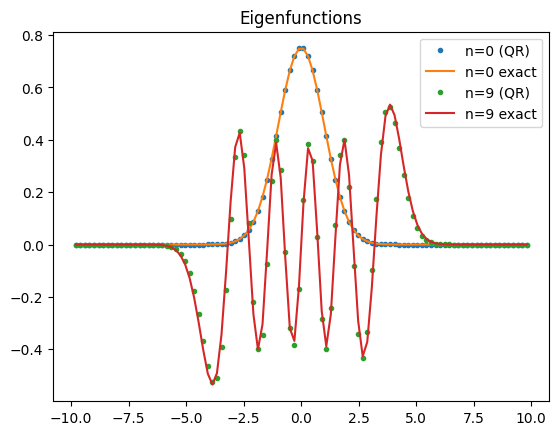

In [21]:
plt.figure()

plt.plot(q, psi_norm[:,0], '.', label="n=0 (QR)")
plt.plot(q, psi_exact(0,q), '-', label="n=0 exact")

plt.plot(q, -psi_norm[:,9], '.', label="n=9 (QR)")     # due to in-built mechanics of array operation
plt.plot(q, psi_exact(9,q), '-', label="n=9 exact")

plt.legend()
plt.title("Eigenfunctions")
plt.show()

<span style="color:red">Problem 10.15                                                                                                                                              
You obtained the spectrum for hydrogen by shooting back in Chapter 3.                                                                                      
Try it again using the finite difference approach – make a matrix by approximating                                                                        
$\qquad\qquad\qquad\displaystyle -\frac{d^2\psi(q)}{dq^2}-\frac{2}{q}\psi(q) = \tilde{E}\psi(q) \qquad\qquad\qquad (10.33)$                                  
using the discretization scheme from                         
$\qquad\qquad\qquad\displaystyle\psi''(q_j)\approx \frac{\psi_{j+1} - 2\psi_j + \psi_{j−1}}{\Delta q^2} \qquad\qquad\qquad  (10.24)  $                                                                                                                                                
with $q_j = j\Delta q$ for $j = 1\rightarrow N$ and $\displaystyle\Delta q = \frac{q_{\infty}}{N+1}$ (notice that we omit the origin).                                    
Using $N = 10000$ and $q_{\infty} = 100,$ find the first six negative (bound-state) energies                                                                
(use the built-in function Eigenvalues this time; the matrices are large).                                                                                                                                        
Fit this data using least squares with a reasonable set of functions of $n$ (an integer in this case) and give the $R^2$ value for your fit                 
(use, as in Problem 10.11, the built-in QR Decomposition to handle the non-square QR decomposition,                                                         
but then solve the least squares problem using UDBacksolve).

Energies: [-0.99997501 -0.24999844 -0.1111108  -0.0624999  -0.0399999  -0.02773694]
Fit coefficient: [-0.99997543]
R^2: 0.9999999976876891


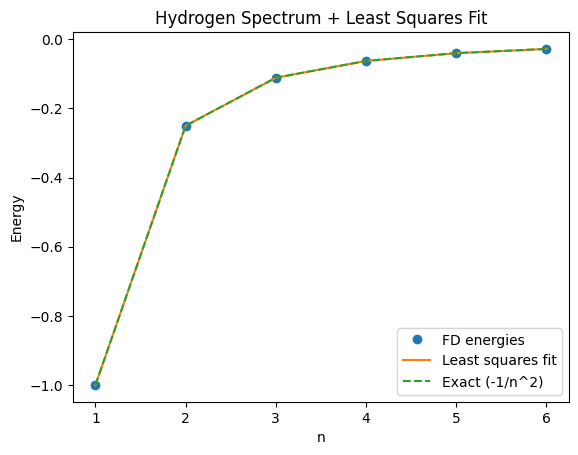

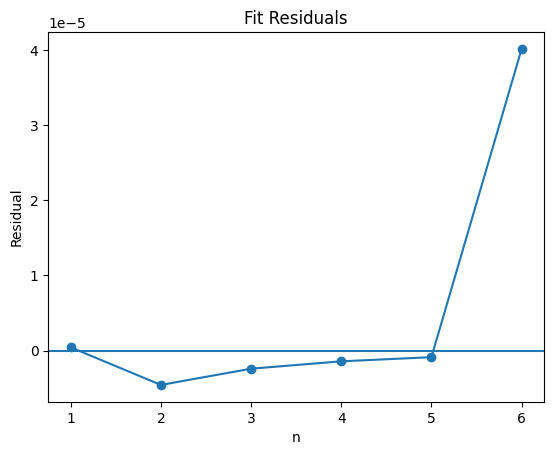

In [22]:
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# PARAMETERS
N = 10000
q_inf = 100
dq = q_inf / (N + 1)

# GRID
q = np.linspace(dq, q_inf - dq, N)

# SECOND DERIVATIVE MATRIX (finite difference)
main = -2.0 * np.ones(N)
off  = 1.0 * np.ones(N-1)
D = diags([off, main, off], [-1, 0, 1]) / dq**2
# POTENTIAL (hydrogen)
V = diags(-2.0 / q, 0)

# HAMILTONIAN
H = -D + V

# EIGENVALUES (first 6 bound states)
E, _ = eigsh(H, k=6, which='SA')
E = np.sort(E)

print("Energies:", E)

# QUANTUM NUMBER
n = np.arange(1, 7)

# LEAST SQUARES FIT: E ≈ a*(1/n^2)
A = (1/n**2).reshape(-1,1)
y = E

# QR decomposition
Q, R = np.linalg.qr(A)

# backsolve
def backsolve(R, y):
    x = np.zeros(len(y))
    for i in range(len(y)-1, -1, -1):
        x[i] = (y[i] - np.dot(R[i,i+1:], x[i+1:])) / R[i,i]
    return x

coeff = backsolve(R, Q.T @ y)

# fitted values
y_fit = A @ coeff

# R^2
R2 = 1 - np.sum((y - y_fit)**2) / np.sum((y - np.mean(y))**2)

print("Fit coefficient:", coeff)
print("R^2:", R2)

# PLOT
plt.figure()

plt.plot(n, y, 'o', label="FD energies")
plt.plot(n, y_fit, '-', label="Least squares fit")
plt.plot(n, -1/n**2, '--', label="Exact (-1/n^2)")

plt.xlabel("n")
plt.ylabel("Energy")
plt.title("Hydrogen Spectrum + Least Squares Fit")
plt.legend()
plt.show()

# OPTIONAL: residual plot
plt.figure()
plt.plot(n, y - y_fit, 'o-')
plt.axhline(0)
plt.xlabel("n")
plt.ylabel("Residual")
plt.title("Fit Residuals")
plt.show()

<span style="color:red">Problem 10.17                                                                                                                                            
Here, we’ll generate the discrete matrix appropriate to the perturbation problem from Problem 10.9.                                                        
Write a function that returns the appropriate matrix $\displaystyle \mathbb{D}+\epsilon\mathbb{\hat{V}}$ for $\mathbb{\hat{V}} = −q$ given $\epsilon$, and the number of grid points $N$.                                                                                                                        
(a) First find the eigenvalues for the matrix with $\epsilon = 0$ and $N = 1000$ with $\Delta q = \frac{1}{N+1} ,$                                       
and verify that errors of order one emerge at the appropriate value of k (the index of the sorted eigenvalues) from Problem 10.8.                                                                                                                  
(b) Now generate the matrix with $\epsilon = 0.1$ and $N = 1000$ with $\Delta q = \frac{1}{N+1} ,$  – find the eigenvalues                                       
(use Eigenvalues, the built-in function, to save time), sort them, and compare with the perturbation result you computed in Problem 10.9                  
– where do the finite difference and perturbative results begin to diverge?

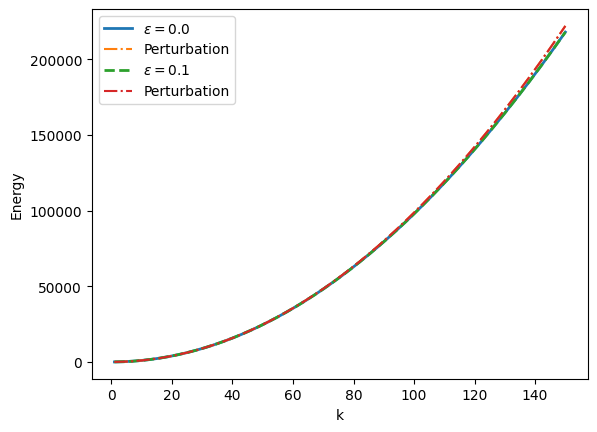

In [23]:
def build_matrix(N, epsilon):
    dq = 1/(N+1)
    q = np.linspace(dq, 1-dq, N)
    D = -2*np.eye(N)
    for i in range(N-1):
        D[i, i+1] = 1
        D[i+1, i] = 1
    D = D / dq**2
    V = np.diag(-q)
    H = -D + epsilon * V
    return H

N = 1000
k = np.arange(1, N+1)
style = ['-', '--']
for i,epsilon in enumerate([0.0, 0.1]):
    H = build_matrix(N, epsilon)
    eigvals = np.linalg.eigvals(H)
    eigvals = np.sort(np.real(eigvals))
    plt.plot(k[:150], eigvals[:150], style[i],label=rf"$\epsilon={epsilon}$", lw=2)
    E_exact = (np.pi**2) * k**2
    E_pert  = E_exact - epsilon/2
    plt.plot(k[:150], E_pert[:150], '-.',label="Perturbation", lw=1.5)
plt.xlabel("k")
plt.ylabel("Energy")
plt.legend()
plt.show()

<span style="color:red">Problem 10.18                                                                                                                                             
Generate the finite difference approximation to the perturbing potential from Problem 10.10, using $N = 1000, \Delta q = \frac{1}{N+1}$, and $\epsilon = .1,$ find the eigenvalues, and sort them.                                                                                                                        
Subtract from each eigenvalue the result of the first-order perturbation analysis you did in Problem 10.10 and plot the result.

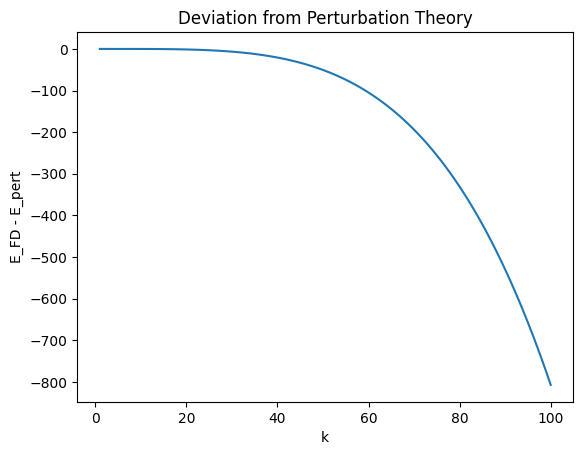

In [24]:
N = 1000
epsilon = 0.1
dq = 1.0 / (N + 1)
q = np.linspace(dq, 1 - dq, N)
D = -2*np.eye(N)
for i in range(N-1):
    D[i, i+1] = 1
    D[i+1, i] = 1
D = D / dq**2
V = np.diag(np.sin(np.pi * q))
H = -D + epsilon * V
E_fd = np.linalg.eigvalsh(H)
k = np.arange(1, N+1)
E_pert = (np.pi**2)*k**2 + (8*epsilon*k**2)/(np.pi*(4*k**2 - 1))
diff = E_fd - E_pert

plt.figure()
plt.plot(k[:100], diff[:100])
plt.xlabel("k")
plt.ylabel("E_FD - E_pert")
plt.title("Deviation from Perturbation Theory")
plt.show()

https://people.reed.edu/~jfrankli/downloads-2/